# Working with the Overture extracts

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kentstephen/bias-bounty-map-tutorial/blob/main/bias-bounty-explore-tutorial.ipynb)


Everything in this notebook runs against the live, public bucket. Nothing is downloaded to disk,
no credentials, no signup.

**Bias Bounties @ Scale** ships five Overture layers for each of four US regions:

| layer | Overture theme / type | geometry |
|---|---|---|
| `overture-buildings` | `buildings` / `building` | polygons |
| `overture-roads` | `transportation` / `segment` (`subtype=road`) | lines |
| `overture-rail` | `transportation` / `segment` (`subtype=rail`) | lines |
| `overture-infrastructure` | `base` / `infrastructure` (stations, airports) | mixed |
| `overture-pois` | `places` / `place` | points |

Alongside them are the reference layers you score Overture *against* (`microsoft-buildings`,
`census-tiger-roads`, `census-acs-housing`, `census-cbp`, `hifld-*`).

The path is always the same:

```
.../geoparquet/<region>/<region>-<layer>.parquet
```

Three things this notebook covers, in order:

1. **Opening the files** (DuckDB and GeoPandas, one line each).
2. **The nested columns.** `names`, `categories` and `sources` are structs and lists, not strings.
   This is the first thing that bites people.
3. **An interactive map** that reads only the footprints in your current viewport, straight off
   the bucket.

## Setup

### Environment

Every dependency version is locked, in three places that agree:

- `pyproject.toml` + `uv.lock`: run `uv sync`, then open the notebook with `uv run jupyter lab`.
- The PEP 723 block in the next cell: run `uvx juv run bias-bounty-explore-tutorial.ipynb` and juv builds the exact environment on the fly.
- The `uv pip` line in the next cell: on Colab, run the cell once (and restart the runtime if Colab asks).


In [ ]:
# /// script
# requires-python = ">=3.12"
# dependencies = [
#     "arro3-core==0.8.1",
#     "duckdb==1.5.4",
#     "geoarrow-rust-io==0.6.1",
#     "geopandas==1.1.4",
#     "ipywidgets==8.1.8",
#     "lonboard==0.16.0",
#     "matplotlib==3.11.0",
#     "numpy==2.5.1",
#     "obstore==0.11.0",
#     "pandas==3.0.3",
#     "pyarrow==24.0.0",
# ]
# ///
# On Colab this installs the locked versions (uv, because pip takes minutes here).
# find_spec("google") first: find_spec("google.colab") raises off Colab, where no
# "google" package exists at all.
import importlib.util
if importlib.util.find_spec("google") and importlib.util.find_spec("google.colab"):
    %pip install -q uv
    !uv pip install --system -q arro3-core==0.8.1 duckdb==1.5.4 geoarrow-rust-io==0.6.1 geopandas==1.1.4 ipywidgets==8.1.8 lonboard==0.16.0 matplotlib==3.11.0 numpy==2.5.1 obstore==0.11.0 pandas==3.0.3 pyarrow==24.0.0
    # Colab only renders third-party widgets (lonboard is one) after this is enabled.
    from google.colab import output
    output.enable_custom_widget_manager()

In [ ]:
import io, math, warnings
warnings.filterwarnings("ignore")
from concurrent.futures import ThreadPoolExecutor

from IPython.display import display

import duckdb
import geopandas as gpd
import ipywidgets as W
import numpy as np
import obstore
import pandas as pd
from arro3.core import Array, DataType, Table
from geoarrow.rust.io import GeoParquetDataset
from lonboard import Map, PathLayer, PolygonLayer, ScatterplotLayer, SolidPolygonLayer, viz
from lonboard.basemap import CartoStyle, MaplibreBasemap
from lonboard.view_state import MapViewState
from matplotlib import colormaps
from matplotlib.colors import LogNorm
from obstore.store import S3Store
from pyarrow.fs import S3FileSystem

ORG, PRODUCT = "humane-intelligence", "bias-bounty-mapping-equity-challenge"
ROOT = f"{ORG}/{PRODUCT}"
REGIONS = ["maricopa-az", "northern-ca", "eastern-ok", "south-central-tx"]

# Two ways in to the same bytes. DuckDB reads over plain https; obstore/pyarrow use s3://.
HTTPS = f"https://data.source.coop/{ROOT}"

def url(region, layer, base=HTTPS):
    return f"{base}/geoparquet/{region}/{region}-{layer}.parquet"

# The bucket is public and needs no auth. But if you have AWS credentials configured (and
# plenty of people do, for work), pyarrow SIGNS the request, S3 rejects it, and you get a
# baffling ACCESS_DENIED / FileNotFoundError on a public file. An anonymous filesystem is
# immune either way. Note it takes the path WITHOUT the s3:// scheme.
ANON = S3FileSystem(anonymous=True, region="us-west-2")

def s3_path(region, layer):
    return f"us-west-2.opendata.source.coop/{ROOT}/geoparquet/{region}/{region}-{layer}.parquet"

# obstore + geoarrow-rust do the interactive map's viewport reads. Same bucket, same bytes.
store = S3Store("us-west-2.opendata.source.coop", region="us-west-2",
                endpoint="https://s3.us-west-2.amazonaws.com", skip_signature=True)

_objs, _ds = {}, {}

def objects(region):
    if region not in _objs:
        _objs[region] = {
            o["path"].split("/")[-1].removeprefix(f"{region}-").removesuffix(".parquet"): o
            for batch in obstore.list(store, f"{ROOT}/geoparquet/{region}/") for o in batch
        }
    return _objs[region]

def dataset(region, layer):
    if (region, layer) not in _ds:
        _ds[(region, layer)] = GeoParquetDataset.open([objects(region)[layer]], store=store)
    return _ds[(region, layer)]

aois = gpd.read_file(io.BytesIO(bytes(
    obstore.get(store, f"{ROOT}/boundaries/all-aois.geojson").bytes()
)))
print(len(objects("northern-ca")), "layers per region")

13 layers per region


### DuckDB

`httpfs` reads the files, `spatial` gives you the `ST_*` functions. Set the S3 region and
path-style addressing on every connection: the bucket name contains dots, so DuckDB's default
virtual-host addressing builds a hostname the TLS certificate doesn't cover.

In [ ]:
con = duckdb.connect()
con.sql("INSTALL httpfs; LOAD httpfs;")
con.sql("INSTALL spatial; LOAD spatial;")
con.sql("SET s3_region='us-west-2'; SET s3_url_style='path';")

con.sql(f"SELECT count(*) AS pois FROM '{url('northern-ca', 'overture-pois')}'").show()

┌────────┐
│  pois  │
│ int64  │
├────────┤
│ 104634 │
└────────┘



### GeoPandas

Pass the `s3://` URI (not `https://`, which pyarrow has no driver for) and a `bbox` to read only
the row groups that intersect it. Here: 4.4M building footprints in the file, ~20k read.

20,066 buildings, CRS OGC:CRS84


<Axes: >

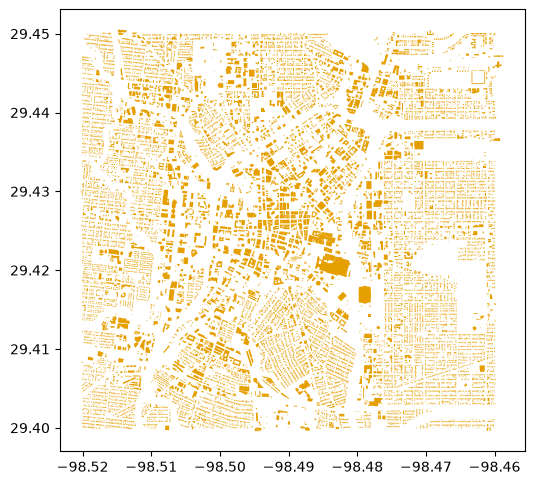

In [ ]:
SAN_ANTONIO = (-98.52, 29.40, -98.46, 29.45)

bldgs = gpd.read_parquet(
    s3_path("south-central-tx", "overture-buildings"), bbox=SAN_ANTONIO, filesystem=ANON,
)
print(f"{len(bldgs):,} buildings, CRS {bldgs.crs}")
bldgs.plot(figsize=(6, 6), color="#E69F00", linewidth=0)


---
# 1. The nested columns

Overture does not flatten its attributes. `names` and `categories` are **structs**; `sources` is a
**list of structs**. Selecting them raw gives you nested objects, so the useful values need to be
reached into.

In [ ]:
con.sql(f'''
    SELECT column_name, column_type
    FROM (DESCRIBE SELECT names, categories, sources FROM '{url("northern-ca", "overture-pois")}')
''').show(max_width=200)

┌─────────────┬────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ column_name │                                                                                      column_type                                                                                       │
│   varchar   │                                                                                        varchar                                                                                         │
├─────────────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ names       │ STRUCT("primary" VARCHAR, common MAP(VARCHAR, VARCHAR), rules STRUCT(variant VARCHAR, "language" VARCHAR, perspectives STRUCT("mode" VARCHAR, countries VARCHAR[]), "value" VARCHAR,

### `names` and `categories` are structs: use dot access

`names.primary` is the one you want 95% of the time. `names.common` is a `MAP`, so it takes a key
(`['en']`), not an index. Only `names.rules` is a list.

In [ ]:
con.sql(f'''
    SELECT names.primary          AS name,
           names.common['en']     AS name_en,
           categories.primary     AS category,
           categories.alternate   AS also,
           confidence
    FROM '{url("northern-ca", "overture-pois")}'
    WHERE names.primary IS NOT NULL
    LIMIT 8
''').show(max_width=140)

┌──────────────────────────┬─────────┬──────────────────────┬──────────────────────────────────────────────┬────────────────────┐
│           name           │ name_en │       category       │                     also                     │     confidence     │
│         varchar          │ varchar │       varchar        │                  varchar[]                   │       double       │
├──────────────────────────┼─────────┼──────────────────────┼──────────────────────────────────────────────┼────────────────────┤
│ J-S Bison Store          │ NULL    │ grocery_store        │ [butcher_shop, shopping]                     │ 0.9770255088806152 │
│ J S Bar Bison Ranch      │ NULL    │ butcher_shop         │ NULL                                         │               0.77 │
│ J Bar S Ranch            │ NULL    │ farm                 │ [livestock_breeder, agriculture]             │ 0.9199122190475464 │
│ Cold Creek Ranch         │ NULL    │ farm                 │ [shopping, pet_services]    

### `sources` is a *list* of structs: index it or unnest it

`sources[1]` is the first source (DuckDB lists are 1-indexed). A feature can have several, so to
count them properly you `unnest`, which explodes one row per source.

In [ ]:
con.sql(f'''
    SELECT names.primary            AS name,
           len(sources)             AS n_sources,
           sources[1].dataset       AS first_dataset,
           sources[1].record_id     AS first_record_id
    FROM '{url("northern-ca", "overture-pois")}'
    WHERE names.primary IS NOT NULL
    LIMIT 8
''').show(max_width=140)

┌──────────────────────────┬───────────┬───────────────┬──────────────────────────┐
│           name           │ n_sources │ first_dataset │     first_record_id      │
│         varchar          │   int64   │    varchar    │         varchar          │
├──────────────────────────┼───────────┼───────────────┼──────────────────────────┤
│ J-S Bison Store          │         2 │ meta          │ 1151581918218753         │
│ J S Bar Bison Ranch      │         2 │ Foursquare    │ 4e3471b4b61cddd1cd32b60a │
│ J Bar S Ranch            │         7 │ meta          │ 158920244470678          │
│ Cold Creek Ranch         │         2 │ meta          │ 1453796768255801         │
│ Cold Creek Compost       │         7 │ meta          │ 102118132117975          │
│ Potter Valley Soapworks  │         2 │ meta          │ 213538275352285          │
│ Matthews Skyline Logging │         7 │ meta          │ 162986847053872          │
│ Ingel Haven Ranch        │         2 │ Foursquare    │ eb009ee43d0346e2770

### The same structs in GeoPandas

You do not need DuckDB for this. `gpd.read_parquet` hands the structs back as plain Python
**dicts**, and the lists of structs as **arrays of dicts**. The `.str` accessor indexes both,
despite the name: it works on any object column, not just strings. Chain it to go a level deeper.

In [ ]:
CHICO = (-121.90, 39.68, -121.76, 39.80)

pois = gpd.read_parquet(
    s3_path("northern-ca", "overture-pois"), bbox=CHICO, filesystem=ANON,
    columns=["names", "categories", "sources", "confidence", "geometry"],
)

pois["name"]      = pois["names"].str["primary"]          # struct -> dict
pois["category"]  = pois["categories"].str["primary"]
pois["n_sources"] = pois["sources"].str.len()             # list of structs -> array of dicts
pois["first_ds"]  = pois["sources"].str[0].str["dataset"]  # chain to index into the first one

pois[["name", "category", "n_sources", "first_ds", "confidence"]].head(8)

,name,category,n_sources,first_ds,confidence
0,Gills Motorworks,automotive_repair,7,meta,0.990219
1,McClelland Air Conditioning,hvac_services,7,meta,0.919912
2,Ginno Construction,construction_services,7,meta,0.919912
3,Prius Offroad,automotive_parts_and_accessories,7,meta,0.919912
4,Featured Local,None,2,Microsoft,0.850000
5,Travidia Incorporated,None,2,Microsoft,0.850000
6,Sel-Tech,engineering_services,2,meta,0.544674
7,Hertz,car_rental_agency,7,meta,0.919912


`explode` is the pandas equivalent of DuckDB's `unnest`: one row per source. It works on a
GeoDataFrame and keeps the geometry, so you can go straight from this to a per-source map.

In [ ]:
pois.explode("sources")["sources"].str["dataset"].value_counts()

sources
Overture-signals    16651
Overture             6107
meta                 3877
Microsoft            1286
Foursquare            546
BrightQuery           243
AllThePlaces          119
DAC                    35
PinMeTo                 1
Name: count, dtype: int64

### Or get typed accessors, with the pyarrow backend

Dict indexing works but it is untyped, and it is slow on big frames. Ask pandas for Arrow-backed
columns instead and you get real `.struct` and `.list` accessors, which stay in Arrow the whole way.

The catch: `dtype_backend` is a **pandas** argument. `gpd.read_parquet` does not accept it, so this
idiom is for the non-spatial columns.

In [ ]:
p = pd.read_parquet(
    s3_path("northern-ca", "overture-pois"), filesystem=ANON,
    columns=["names", "categories", "sources", "confidence"],
    dtype_backend="pyarrow",
)

print("fields on `names`:", p["names"].struct.dtypes.index.tolist())

p.assign(
    name      = p["names"].struct.field("primary"),
    category  = p["categories"].struct.field("primary"),
    n_sources = p["sources"].list.len(),
    first_ds  = p["sources"].list[0].struct.field("dataset"),
)[["name", "category", "n_sources", "first_ds", "confidence"]].head(8)

fields on `names`: ['primary', 'common', 'rules']


,name,category,n_sources,first_ds,confidence
0,J-S Bison Store,grocery_store,2,meta,0.977026
1,J S Bar Bison Ranch,butcher_shop,2,Foursquare,0.77
2,J Bar S Ranch,farm,7,meta,0.919912
3,Cold Creek Ranch,farm,2,meta,0.580258
4,Cold Creek Compost,agricultural_service,7,meta,0.919912
5,Potter Valley Soapworks,beauty_salon,2,meta,0.525221
6,Matthews Skyline Logging,logging_contractor,7,meta,0.919912
7,Ingel Haven Ranch,pet_services,2,Foursquare,0.77


# The interactive map: draw a box, get the code

Same map as notebook 21 (pick a region, tick up to three layers, read them off the bucket), plus
one thing: **draw a box on the map and it hands you the code to pull exactly those features.**

Hit the **▢ button at the lower-right of the map**, click two corners, and a box is drawn. The
panel below the map then fills with a **complete, copy-pasteable snippet**: the box and every
ticked layer are filled in, DuckDB reads them straight off the live bucket, and lonboard's `viz()`
puts the result back on a map. A **copy snippet** button puts
it on the clipboard; **clear** dismisses it.

Everything else is 21 verbatim. `LAYERS` still configures every layer in one place; the polygon
fills still paint on construct via a per-row colour array (lonboard
[#1044](https://github.com/developmentseed/lonboard/issues/1044)).


## Every layer, in one place

One entry per layer. `color` is a flat colour; `ramp` means it is a **choropleth**, coloured by that
column. Everything else is a lonboard trait you can change without touching any other code.

Colours are Okabe-Ito, which stay distinct under colour-vision deficiency. The choropleths use
cividis, a blue-to-yellow ramp, for the same reason.

In [ ]:
MAX_LAYERS = 3      # layers on at once. Each one is its own read and its own GPU buffers.
MINZOOM = 13.0      # below this, the big layers show their row-group boxes instead of features
BIG = 50_000        # rows: over this, a layer is only read for the viewport, never whole
HEAVY = 150_000     # rows on screen, all layers: past this the status line tells you to zoom in

LAYERS = {
    # name                    how it is drawn                                     what it is
    "census-acs-housing": {"ramp": "housing_units", "opacity": 0.85, "line": [40, 40, 40]},
    "census-cbp":         {"ramp": "cbp_estab",     "opacity": 0.85, "line": [40, 40, 40]},

    "hifld-hospitals":    {"color": "#D55E00", "opacity": 1.0,  "radius": 6},
    "hifld-fire-stations":{"color": "#E69F00", "opacity": 1.0,  "radius": 5},
    "hifld-ems-stations": {"color": "#CC79A7", "opacity": 1.0,  "radius": 5},
    "hifld-schools":      {"color": "#56B4E9", "opacity": 1.0,  "radius": 4},

    "overture-buildings": {"color": "#E69F00", "opacity": 0.8},
    "overture-roads":     {"color": "#56B4E9", "opacity": 0.9,  "width": 1.5},
    "overture-rail":      {"color": "#CC79A7", "opacity": 0.9,  "width": 1.5},
    "overture-infrastructure": {"color": "#009E73", "opacity": 0.9, "radius": 4, "width": 1.5},
    "overture-pois":      {"color": "#F0E442", "opacity": 0.9,  "radius": 3},

    "microsoft-buildings":{"color": "#0072B2", "opacity": 0.8},
    "census-tiger-roads": {"color": "#D55E00", "opacity": 0.9,  "width": 1.5},
}

CIVIDIS = colormaps["cividis"]
MISSING = (120, 120, 120)      # a tract with no count is grey, NOT the dark end of the ramp

def cividis_fill(values):
    '''count per tract -> (N, 3) uint8 cividis, log-normed. Log because tract counts are skewed:
    on a linear ramp almost every tract lands in the bottom bucket and the map goes flat.'''
    v = np.asarray(values, dtype="float64")
    finite = v[np.isfinite(v) & (v > 0)]
    norm = LogNorm(vmin=max(finite.min(), 1), vmax=max(finite.max(), 2))
    rgb = (CIVIDIS(norm(np.where(v > 0, v, np.nan)))[:, :3] * 255).astype("uint8")
    rgb[~np.isfinite(v) | (v <= 0)] = MISSING
    return rgb

## Building a layer

Two paths, and the split is deliberate.

A **choropleth** is read whole through GeoPandas and built with `PolygonLayer.from_geopandas`.
That is exactly what notebooks 12 and 14 do, and they render. These are 591 to 6,012 tracts: small.

Everything **else** is read arrow-native through geoarrow-rust, and only for the viewport when the
layer is big. That is the cloud-native read this whole project is about, and it is what lets you
put a million buildings on a map without downloading a million buildings.

In [ ]:
def choropleth(region, name, cfg):
    '''A census layer: one polygon per tract, filled by its count.'''
    g = gpd.read_parquet(s3_path(region, name), filesystem=ANON)
    return [PolygonLayer.from_geopandas(
        g,
        get_fill_color=cividis_fill(g[cfg["ramp"]]),
        get_line_color=cfg.get("line", [40, 40, 40]),
        line_width_min_pixels=0.5,
        opacity=cfg["opacity"],
        pickable=True,
    )]

# geoarrow tells us what the geometry IS, so we can build the right layer class outright rather
# than letting viz() guess. It is also just clearer: a point becomes a ScatterplotLayer, a line a
# PathLayer, a polygon a PolygonLayer, and you can see which is which.
GEOM = {
    "geoarrow.point":           "point",
    "geoarrow.multipoint":      "point",
    "geoarrow.linestring":      "line",
    "geoarrow.multilinestring": "line",
    "geoarrow.polygon":         "area",
    "geoarrow.multipolygon":    "area",
}

def geom_kind(table):
    md = table.schema.field("geometry").metadata_str
    return GEOM.get(md.get("ARROW:extension:name"))

def one_layer(table, kind, cfg):
    """A table of one geometry type -> the lonboard layer for it. Every trait comes from cfg, so
    LAYERS is the only place appearance is decided."""
    if kind == "point":
        return ScatterplotLayer(table=table, get_fill_color=cfg["color"],
                                radius_min_pixels=cfg.get("radius", 3),
                                opacity=cfg["opacity"], pickable=True)
    if kind == "line":
        return PathLayer(table=table, get_color=cfg["color"],
                         width_min_pixels=cfg.get("width", 1.5),
                         opacity=cfg["opacity"], pickable=True)
    # Overture polygons (buildings, and infrastructure's airports) draw as STROKED OUTLINES, not a
    # solid fill: filled=False, stroked=True. An outline is enough to read a footprint against the
    # DarkMatter basemap, it is lighter than tessellating a fill for 10^5 buildings, and a stroke
    # renders on both the constructor and a live layer swap (lonboard #1044 only starves polygon
    # FILLS of paint, never the outline).
    return PolygonLayer(table=table, filled=False, stroked=True,
                        get_line_color=cfg["color"], line_width_min_pixels=0.5,
                        opacity=cfg["opacity"], pickable=True,
                        auto_highlight=table.num_rows <= 50_000)

def features(region, name, cfg, bbox):
    """Everything that is not a choropleth. Read the viewport if the layer is big, the whole thing
    if it is not."""
    ds = dataset(region, name)
    table = ds.read(bbox=bbox) if (ds.num_rows > BIG and bbox) else ds.read()
    if table.num_rows == 0:
        return []
    if "bbox" in table.column_names:
        # The GeoParquet covering column. It is the spatial index the bbox reads prune on, not
        # data about the feature, so keep it out of the click tooltip.
        table = table.drop_columns(["bbox"])

    kind = geom_kind(table)
    if kind:
        return [one_layer(table, kind, cfg)]

    # Mixed geometry (overture-infrastructure: stations are points, airports polygons, aprons
    # lines). viz() is used ONLY to split it by type; the layers themselves are still built here,
    # explicitly, from the tables it separated out.
    return [one_layer(l.table, k, cfg)
            for l in viz(table).layers
            if (k := {"ScatterplotLayer": "point", "PathLayer": "line",
                      "PolygonLayer": "area"}.get(type(l).__name__))]

def build(region, name, bbox=None):
    cfg = LAYERS[name]
    return choropleth(region, name, cfg) if "ramp" in cfg else features(region, name, cfg, bbox)

def aoi_layer(region):
    return PolygonLayer.from_geopandas(
        aois[aois.folder == region], filled=False, stroked=True,
        get_line_color=[255, 255, 255], line_width_min_pixels=1.5,
    )

def aoi_bbox(region):
    return tuple(aois[aois.folder == region].total_bounds)

# Below MINZOOM a big layer does not draw its features, it draws its ROW-GROUP BOXES: the file's own
# spatial index, made visible. Each box is a chunk of the parquet file, and a viewport read fetches
# exactly the boxes it touches. It is the most honest picture of what cloud-native reading is doing,
# and it costs one footer read rather than a million buildings.
#
# Achromatic on purpose: grey is file structure, colour is data.
BOX_LINE, BOX_FILL = "#B0B0B0", "#B0B0B012"

def partition_boxes(region, name):
    bounds = dataset(region, name).fragments[0].row_groups_bounds()
    n = len(bounds)
    table = Table.from_arrays(
        [bounds, Array([name] * n, DataType.string()), Array(np.arange(n), DataType.int32())],
        names=["geometry", "layer", "row_group"],
    )
    # NOT pickable: these cover the whole viewport, so a tooltip on them makes the features
    # underneath impossible to click.
    return [PolygonLayer(table=table, get_fill_color=BOX_FILL, get_line_color=BOX_LINE,
                         stroked=True, filled=True, line_width_min_pixels=1, pickable=False)]

def is_big(region, name):
    return "ramp" not in LAYERS[name] and dataset(region, name).num_rows > BIG

## Finding a place

Photon (Komoot's geocoder, OpenStreetMap data, no API key). Type a place, press **Enter**, and
the hits land in a list, biased to the current region's bounding box. Pick one and the map goes
there.

In [ ]:
import json, urllib.parse, urllib.request

PHOTON = "https://photon.komoot.io/api"
JUMP_ZOOM = 14.0     # zoom to land on for a hit with no extent (an address, a shop)

def photon(query, bbox, limit=6):
    '''Geocode `query`, biased to `bbox`. Returns [(label, (lon, lat, extent)), ...] where
    extent is Photon's own bounding box for the feature (towns and counties have one; a single
    address does not), in its [minlon, maxlat, maxlon, minlat] order.'''
    params = urllib.parse.urlencode({
        "q": query,
        "limit": limit,
        "bbox": ",".join(f"{v:.4f}" for v in bbox),
    })
    with urllib.request.urlopen(f"{PHOTON}?{params}", timeout=6) as resp:
        features = json.load(resp)["features"]

    hits, seen = [], {}
    for f in features:
        p = f["properties"]
        # Photon labels vary by feature type: a town has name+state, an address has street+city.
        # dict.fromkeys de-dupes while keeping order ("Chico, Chico, CA" -> "Chico, CA").
        label = ", ".join(dict.fromkeys(
            x for x in (p.get("name"), p.get("city"), p.get("county"), p.get("state")) if x
        ))
        # ipywidgets.Select keys its options by label, so two identical labels collapse into one.
        seen[label] = seen.get(label, 0) + 1
        if seen[label] > 1:
            label = f"{label} ({seen[label]})"
        lon, lat = f["geometry"]["coordinates"]
        hits.append((label, (lon, lat, p.get("extent"))))
    return hits

def hit_to_view(hit):
    '''Where the camera should land for a geocoder hit.'''
    lon, lat, extent = hit
    if not extent:
        return MapViewState(longitude=lon, latitude=lat, zoom=JUMP_ZOOM)
    minlon, maxlat, maxlon, minlat = extent
    vs = bbox_to_view((minlon, minlat, maxlon, maxlat))
    # Never land below MINZOOM: you asked to go to a place, so you want to see its features, not
    # the row-group boxes. Never land above 16 either, or a small town fills the screen.
    return MapViewState(longitude=vs.longitude, latitude=vs.latitude,
                        zoom=min(max(vs.zoom, MINZOOM), 16.0))

## Viewport &harr; bounding box

Turning the camera into a box to read. This needs to know how wide the map is in pixels, which
lonboard does not report, so it is a constant. Too small and the edges of the map stay empty; too
large and you read features you do not draw. Erring large.

In [ ]:
VIEW_W, VIEW_H = 1400, 700

def _lat_to_y(lat):
    s = math.sin(math.radians(max(min(lat, 85.0), -85.0)))
    return 0.5 - math.log((1 + s) / (1 - s)) / (4 * math.pi)

def _y_to_lat(y):
    return math.degrees(2 * math.atan(math.exp((0.5 - y) * 2 * math.pi)) - math.pi / 2)

def view_to_bbox(vs):
    world = 512 * (2 ** vs.zoom)
    half_lon = 360.0 * VIEW_W / world / 2
    yc, half_y = _lat_to_y(vs.latitude), VIEW_H / world / 2
    return (vs.longitude - half_lon, _y_to_lat(yc + half_y),
            vs.longitude + half_lon, _y_to_lat(yc - half_y))

def bbox_to_view(bbox, pad=1.15):
    xmin, ymin, xmax, ymax = bbox
    dlon = max((xmax - xmin) * pad, 1e-6)
    dy = max(abs(_lat_to_y(ymin) - _lat_to_y(ymax)) * pad, 1e-9)
    zoom = max(0.0, min(18.0, min(math.log2(360.0 * VIEW_W / 512 / dlon),
                                  math.log2(VIEW_H / 512 / dy))))
    return MapViewState(longitude=(xmin + xmax) / 2, latitude=(ymin + ymax) / 2, zoom=zoom)

## The map

Two update paths, and the split is deliberate. A **layer-set change** (tick, untick, reorder,
region, geocode) constructs a new `Map` and swaps it into a Box: a fresh construct always paints
polygon fills, which dodges lonboard
[#1044](https://github.com/developmentseed/lonboard/issues/1044) (fills handed to a *live* map do
not paint until the camera moves). A **camera move** mutates the live map's `layers` in place: the
camera just moved, so fills paint, and the widget does not tear down and reload the basemap on
every pan.

Everything runs in the handler of a browser event, on the kernel's main loop: no threads, no
timers, no `Output` widgets. Colab drops widget updates that originate anywhere else; JupyterLab
and VSCode are just more forgiving. That is affordable because lonboard's frontend already
debounces camera syncs (~300 ms), and a read is skipped entirely while the previous read (padded
by `READ_PAD`) still covers the viewport.


In [ ]:
OPENING = ["census-acs-housing", "hifld-hospitals"]

# "built" maps layer name -> the lonboard layers currently drawn for it. Restacking is then a
# reshuffle of objects we already have; only the READ (network) costs.
state = {"region": "northern-ca", "layers": list(OPENING), "built": {}, "map": None,
         "view": None, "bbox": None,   # "bbox" is the last box drawn on the map (minx,miny,maxx,maxy)
         "read_key": None, "read_bbox": None}   # what the last read covered, and for which layers

# ONE RULE replaces a lot of machinery that used to live here: everything runs in the handler
# of a browser event (a checkbox toggle, a camera sync, a drawn box), on the kernel's main loop.
# No threads, no timers, no Output widgets. That is not a style choice. Colab drops widget
# updates that originate anywhere else (JupyterLab and VSCode deliver them from any thread, which
# is why a background-Timer design worked there and not in Colab), and it routes an Output's
# display/clear against the whole cell's output area. Trait assignment from a main-loop event
# handler is the one path every frontend agrees on.
canvas = W.VBox([])
status = W.HTML()
# The drawn-box query lands BELOW the map: a VBox whose children are assigned, like canvas.
snippet_out = W.VBox([])

def layer_stack():
    '''The lonboard layers to draw, in order: the ticked layers bottom-to-top, AOI outline on top.'''
    return [l for name in state["layers"] for l in state["built"].get(name, [])] + [aoi_layer(state["region"])]

def rebuild():
    """Construct a NEW Map and swap it into the Box. Used for LAYER-SET changes (tick, untick,
    reorder, region, geocode): those are deliberate, occasional clicks, so a one-off reload is fine,
    and a fresh construct is the surest way to get a clean paint."""
    m = Map(layer_stack(), height=650, view_state=state["view"], show_tooltip=True,
            basemap=MaplibreBasemap(style=CartoStyle.DarkMatter))
    m.observe(on_camera, names="view_state")
    # A fresh Map starts with selected_bounds=None, so re-attach the draw-box observer on every
    # rebuild -- same reason on_camera is re-attached here rather than once at construction.
    m.observe(on_select, names="selected_bounds")
    state["map"] = m
    canvas.children = (m,)

repaint = rebuild   # the controls cell calls repaint() for untick/reorder; both are layer-set changes

def restack():
    """MUTATE the existing map's layers in place. Used for CAMERA-DRIVEN reads (pan/zoom). The Map
    instance PERSISTS, so the camera stays put and the widget does NOT tear down and reload the
    basemap on every move -- reconstructing on every settle is what made the map flash and freeze.
    map.layers is a trait, so the swap lands from the background camera-timer thread."""
    if state["map"] is None:
        rebuild()
    else:
        state["map"].layers = layer_stack()

READ_PAD = 1.35     # read this much around the viewport, so a small pan needs no new read

def pad_bbox(b, f=READ_PAD):
    dx, dy = (b[2] - b[0]) * (f - 1) / 2, (b[3] - b[1]) * (f - 1) / 2
    return (b[0] - dx, b[1] - dy, b[2] + dx, b[3] + dy)

def covers(outer, inner):
    return (outer[0] <= inner[0] and outer[1] <= inner[1]
            and outer[2] >= inner[2] and outer[3] >= inner[3])

def render(view=None, fresh=True):
    """Read what the current selection needs for this viewport, then show it. `fresh` picks how:
    rebuild (a new Map) for layer-set changes, restack (mutate the live map) for camera moves.
    Runs synchronously, in whatever browser-event handler called it; the covers() guard below is
    what keeps that affordable.

    There is no re-entrancy guard. There WAS one, and it was the bug: rebuilding the map makes the
    new Map emit a view_state event, which triggers a render, so a click arriving during that
    window was silently dropped and the checkbox you just ticked did nothing."""
    show = rebuild if fresh else restack
    try:
        region, chosen = state["region"], state["layers"]
        state["view"] = view = view or state["view"] or bbox_to_view(aoi_bbox(region))

        if not chosen:
            state["built"], state["read_key"], state["read_bbox"] = {}, None, None
            show()
            status.value = "Pick a layer."
            return

        # Below MINZOOM the big layers show their row-group boxes instead of a million features.
        boxed = [n for n in chosen if is_big(region, n) and view.zoom < MINZOOM]
        read = [n for n in chosen if n not in boxed]
        bbox = view_to_bbox(view)

        # A camera move that stays inside what the last read covered (plus its pad) has nothing
        # to fetch and nothing to redraw: the drawn layers are already right.
        if not fresh and state["read_key"] == (region, tuple(read), tuple(boxed)) \
                and state["read_bbox"] and covers(state["read_bbox"], bbox):
            return

        status.value = "<b>reading…</b> the read covers your whole viewport. Zoom in for a smaller one."
        # The read IS the cost (network), and obstore and geoarrow are Rust: they drop the GIL.
        # So fetch every layer at once instead of one after another.
        padded = pad_bbox(bbox)
        with ThreadPoolExecutor(max_workers=max(len(read), 1)) as pool:
            built = dict(zip(read, pool.map(lambda n: build(region, n, padded), read)))
        built.update({n: partition_boxes(region, n) for n in boxed})

        state["built"] = built
        state["read_key"], state["read_bbox"] = (region, tuple(read), tuple(boxed)), padded
        show()

        # SAY WHAT IS ON SCREEN. Every ticked layer, with its row count, in draw order.
        drawn = sum(l.table.num_rows for n in read for l in built[n])
        parts = [f"{sum(l.table.num_rows for l in built[n]):,} {n}" for n in read]
        parts += [f"{sum(l.table.num_rows for l in built[n])} row-group boxes ({n})" for n in boxed]
        line = f"<b>zoom {view.zoom:.1f}</b> · " + " · ".join(parts)

        if boxed:
            line += (f" · <b>zoom past {MINZOOM:.0f}</b> to load "
                     f"{' and '.join(boxed)} for real.")
        elif drawn > HEAVY:
            line += (f" · <b>{drawn:,} features on screen.</b> Zoom in, or untick a layer, "
                     f"for a faster map.")
        status.value = line
    except Exception as exc:
        # An exception in a comm handler can vanish without a trace in some frontends: the map
        # would simply stop updating and nothing would say why. So say why, then raise.
        status.value = f"<b style='color:#F0E442'>failed:</b> {type(exc).__name__}: {exc}"
        raise

def same_view(a, b):
    return a and b and (round(a.longitude, 6), round(a.latitude, 6), round(a.zoom, 4)) == \
                       (round(b.longitude, 6), round(b.latitude, 6), round(b.zoom, 4))

def on_camera(change):
    """Camera syncs arrive as comm messages, already debounced (~300 ms) by lonboard's frontend,
    so handle them here and now, synchronously. The echo check drops the event the map emits for
    a view we just handed it."""
    if same_view(change["new"], state["view"]):
        return
    # fresh=False: a camera move mutates the live map, it does NOT reconstruct it (no flash).
    render(change["new"], fresh=False)


# ## Draw a box -> a copyable query
#
# The map has a built-in bounding-box tool (lonboard 0.16 `Map.selected_bounds`): the box button at
# the lower-right, click two corners. When the box completes, selected_bounds is pushed back here as
# (minx, miny, maxx, maxy) in EPSG:4326, and on_select turns it into a standalone snippet for exactly
# the ticked layers, clipped to that box, and drops it into snippet_out with copy + clear buttons.

import html as _html

def copy_button(code):
    """A copy-to-clipboard button. Kernel-side Python cannot reach the browser clipboard, so the
    copy happens entirely in an inline onclick: the snippet is JSON-encoded (JSON is a valid JS
    string literal) and the whole handler HTML-escaped so it can live inside the attribute."""
    js = (f"const b = this; navigator.clipboard.writeText({json.dumps(code)})"
          ".then(() => { b.textContent = 'copied ✓';"
          " setTimeout(() => { b.textContent = 'copy snippet'; }, 1200); });")
    return W.HTML(f'<button class="bb-copy" onclick="{_html.escape(js, quote=True)}">copy snippet</button>')

# Clearing has to reach back into the kernel (drop state["bbox"], or the snippet reappears on the
# next tick/untick), so unlike copy this is a real ipywidgets Button. One instance, re-attached to
# snippet_out's children each time; emptying the children only removes it from view, it survives.
clear_b = W.Button(description="clear", layout=W.Layout(width="70px"))

def on_clear(_):
    state["bbox"] = None
    if state["map"] is not None:
        state["map"].selected_bounds = None   # drop the map's own rectangle too (on_select ignores None)
    snippet_out.children = ()
    status.value = "snippet cleared. Draw another box (box button, lower-right) for a new one."

clear_b.on_click(on_clear)

def show_snippet():
    """(Re)render the query for the last-drawn box below the map. Called on a fresh box, and on a
    layer/region change so the query keeps up with what is ticked. No box yet -> show nothing."""
    if not state["bbox"]:
        snippet_out.children = ()
        return
    if not state["layers"]:
        snippet_out.children = (W.HTML("<i>Tick at least one layer, then draw a box.</i>"),)
        return
    code = render_snippet(state["region"], state["layers"], state["bbox"])
    header = W.HBox(
        [W.HTML("<b>Query for the box you drew</b>"),
         copy_button(code), clear_b],
        layout=W.Layout(align_items="center"))
    header.add_class("bb-snippet")
    snippet_out.children = (header, W.HTML(f'<pre class="bb-code">{_html.escape(code)}</pre>'))

def on_select(change):
    bounds = change["new"]
    if not bounds:                       # a fresh Map resets selected_bounds to None on rebuild
        return
    state["bbox"] = tuple(bounds)
    show_snippet()
    status.value = ("<b>box drawn.</b> The snippet is below the map: copy it. "
                    "Draw again (box button, lower-right) to update it.")


## The query builder

In [ ]:
# One snippet, standalone: DuckDB reads the drawn box straight off the bucket (the bbox.*
# comparisons prune row groups -- the measured-fast pattern from notes/duckdb-source-coop-access.md),
# materializes it as a table named after the layer, and hands it to lonboard's viz(). The read is
# over the plain HTTPS proxy: no region, no creds, no signing. Every ticked layer becomes a
# variable; the recipient points `url` at whichever one they want on the map.

def layer_url(region, name):
    return f"https://data.source.coop/{ROOT}/geoparquet/{region}/{region}-{name}.parquet"

def render_snippet(region, layers, bbox):
    xmin, ymin, xmax, ymax = bbox
    var = {n: f"{region}-{n}".replace("-", "_") for n in layers}
    width = max(len(v) for v in var.values())
    files = "\n".join(f'{var[n]:<{width}} = "{layer_url(region, n)}"' for n in layers)
    first = layers[0]
    count = {2: "two", 3: "three"}.get(len(layers), str(len(layers)))
    pick = (f"      # pick one of the {count} above and fill in here"
            if len(layers) > 1 else "")
    plural = "layers" if len(layers) > 1 else "layer"
    return f'''
import duckdb
from lonboard import viz

con = duckdb.connect()
con.sql("INSTALL httpfs; LOAD httpfs; INSTALL spatial; LOAD spatial")

# the box you drew (EPSG:4326)
xmin, ymin, xmax, ymax = {xmin:.6f}, {ymin:.6f}, {xmax:.6f}, {ymax:.6f}

# the {plural} you added (variable = filename)
{files}

url  = {var[first]}{pick}
name = url.split("/")[-1].removesuffix(".parquet")       # the filename, e.g. "{region}-{first}"

# CREATE ... AS materializes the clipped box into a table named after the layer, so con.table(name)
# hands it back to viz. The table name is quoted because the filename has dashes.
con.sql(f"""
    CREATE OR REPLACE TABLE '{{name}}' AS
    SELECT geometry::geometry AS geometry, * EXCLUDE (geometry)
    FROM read_parquet('{{url}}')
    WHERE bbox.xmin <= {{xmax}} AND bbox.xmax >= {{xmin}}
      AND bbox.ymin <= {{ymax}} AND bbox.ymax >= {{ymin}}
""")
con.sql(f"FROM '{{name}}'").show()
viz(con.table(name))'''

## Controls, and the map

In [ ]:
# The panel sits against a DarkMatter basemap, so it is dark and monospaced: it should read as part
# of the map, not as leftover notebook chrome. Only the swatches carry colour, and they are the
# same hues the layers actually draw in.
# The <style> ships INSIDE the app's widget tree (an HTML widget child), not as its own display:
# Colab sandboxes every display into its own iframe, so a separately-displayed style never reaches
# the widgets it is meant to style.
styles = W.HTML('''
<style>
.bb-panel {
  background: #12151A; border: 1px solid #262C34; border-radius: 6px;
  padding: 14px 16px; margin-bottom: 8px; width: max-content;
  font-family: ui-monospace, SFMono-Regular, Menlo, monospace;
}
.bb-panel .widget-label, .bb-panel label, .bb-panel select, .bb-panel button,
.bb-panel input[type="text"], .bb-panel .widget-html-content {
  font-family: ui-monospace, SFMono-Regular, Menlo, monospace !important;
  font-size: 12px !important; color: #C6CDD6;
}
.bb-panel select, .bb-panel button, .bb-panel input[type="text"] {
  background: #1B2029; border: 1px solid #2E3743; border-radius: 4px; color: #C6CDD6;
}
.bb-panel input[type="text"]::placeholder { color: #5C6672; }
.bb-panel button:hover:enabled { background: #262E3A; }
.bb-panel button:disabled { opacity: 0.4; }
.bb-panel select option:checked { background: #2E3743; }
.bb-head {
  font-size: 10px !important; letter-spacing: 0.12em; text-transform: uppercase;
  color: #6E7A88 !important; margin-bottom: 6px;
}
/* The status line is a fixed-height strip. It used to reflow the whole panel every time the
   feature counts changed length, which is most of what made this feel unstable. */
.bb-status {
  min-height: 20px; margin-top: 10px; padding-top: 8px; border-top: 1px solid #262C34;
  color: #8E99A6 !important;
}
.bb-status b { color: #E6EDF3; font-weight: 600; }
/* The swatch and its checkbox are a flex row, and the swatch is centred in it. It used to be a
   div nudged down with a magic margin-top, which lined up at one font size and no other. */
.bb-swatch { display: flex; align-items: center; height: 100%; }
.bb-swatch .widget-html-content { display: flex; align-items: center; line-height: 1; }
.bb-row { align-items: center; }
.bb-row .widget-checkbox { margin: 0; }
/* The snippet header row (label + copy + clear), below the map. Same chrome as the panel, so it
   reads as part of the tool. .bb-copy is a raw <button> in an HTML widget; the clear button is a
   jupyter-button. Style both to match. */
.bb-snippet { margin: 8px 0 0 0; }
.bb-snippet .widget-html-content {
  font-family: ui-monospace, SFMono-Regular, Menlo, monospace; font-size: 12px; color: #8E99A6;
}
.bb-snippet b { color: #E6EDF3; }
.bb-copy, .bb-snippet .jupyter-button {
  background: #1B2029; border: 1px solid #2E3743; border-radius: 4px; color: #C6CDD6;
  font-family: ui-monospace, SFMono-Regular, Menlo, monospace; font-size: 12px;
  height: 24px; padding: 0 10px; margin-left: 10px; cursor: pointer;
}
.bb-copy:hover, .bb-snippet .jupyter-button:hover { background: #262E3A; }
/* The generated query below the map: snippet_out holds widgets, not markdown, so the code block
   is a <pre> styled here rather than by the notebook's renderer. */
.bb-code {
  background: #12151A; border: 1px solid #262C34; border-radius: 6px;
  padding: 12px 14px; margin: 8px 0 0 0; overflow-x: auto; max-width: 920px;
  font-family: ui-monospace, SFMono-Regular, Menlo, monospace; font-size: 12px;
  color: #C6CDD6; line-height: 1.5;
}
</style>
''')

SWATCH_OFF = "#3A424D"
CIVIDIS_CHIP = "linear-gradient(90deg, {}, {}, {})".format(
    *["#%02X%02X%02X" % tuple(int(c) for c in np.array(CIVIDIS(x)[:3]) * 255)
      for x in (0.0, 0.5, 1.0)]
)

def swatch(name, on):
    """The layer list IS the legend: each row shows the colour that layer draws in. A choropleth
    does not have a colour, it has a ramp, so its chip IS the ramp, sampled from cividis itself."""
    cfg = LAYERS[name]
    bg = SWATCH_OFF if not on else (CIVIDIS_CHIP if "ramp" in cfg else cfg["color"])
    return f'<div style="width:11px;height:11px;border-radius:2px;background:{bg}"></div>'

# ---- layers ----------------------------------------------------------------------------------
checks, marks, rows = {}, {}, []

def sync_cap():
    """At the cap, the boxes you cannot tick go dead. A limit you can SEE beats a refusal after the
    fact, which just reads as a bug. Ticked boxes stay live, so you can always trade one out."""
    at_cap = len(state["layers"]) >= MAX_LAYERS
    for name, box in checks.items():
        box.disabled = at_cap and not box.value

def on_check(change):
    name = change["owner"].description
    if change["new"]:
        if len(state["layers"]) >= MAX_LAYERS:
            change["owner"].value = False
            status.value = f"<b>{MAX_LAYERS} layers maximum.</b> Untick one to make room."
            return
        state["layers"].append(name)      # newly ticked: drawn last, so it lands on top
    else:
        state["layers"].remove(name)
    marks[name].value = swatch(name, change["new"])
    sync_cap()
    sync_order(keep=name if change["new"] else None)
    if state["bbox"]:
        show_snippet()   # keep the query in step with what is ticked
    if change["new"]:
        render()          # a newly ticked layer has to be read before it can be drawn
    else:
        state["built"].pop(name, None)
        repaint()         # unticking is just a restack: drop it and repaint, no network

for name in LAYERS:
    on = name in state["layers"]
    checks[name] = W.Checkbox(value=on, description=name, indent=False,
                              layout=W.Layout(width="196px", margin="0", flex="0 0 auto"))
    marks[name] = W.HTML(swatch(name, on),
                         layout=W.Layout(width="19px", margin="0", flex="0 0 auto"))
    marks[name].add_class("bb-swatch")
    checks[name].observe(on_check, names="value")
    row = W.HBox([marks[name], checks[name]],
                 layout=W.Layout(align_items="center", margin="0", height="22px"))
    row.add_class("bb-row")
    rows.append(row)

# ---- region ----------------------------------------------------------------------------------
region_w = W.Dropdown(options=REGIONS, value=state["region"], description="",
                      layout=W.Layout(width="215px"))

def on_region(change):
    state["region"] = change["new"]
    search_w.value = ""                   # the old region's hits are meaningless here
    state["bbox"] = None                  # a box drawn in the old region is meaningless here
    show_snippet()
    show_hits(())
    render(bbox_to_view(aoi_bbox(change["new"])))

region_w.observe(on_region, names="value")

# ---- find a place ----------------------------------------------------------------------------
search_w = W.Text(placeholder="town, county, address… then Enter", continuous_update=False,
                  description="", layout=W.Layout(width="215px"))
hits_w = W.Select(options=(), rows=6, description="",
                  layout=W.Layout(width="215px", display="none", margin="6px 0 0 0"))

def show_hits(hits):
    """Fill the results list, or hide it. An empty Select still reserves its rows, so it sits under
    the search box as an empty outlined panel that looks like a broken widget. Assigning .options
    fires the value observer, so mute it across the swap: otherwise typing flies the camera to
    whatever happens to sort first."""
    hits_w.unobserve(on_hit, names="value")
    hits_w.options = tuple(hits)
    hits_w.value = None
    hits_w.observe(on_hit, names="value")
    hits_w.layout.display = "flex" if hits else "none"

def on_search(change):
    """The search box syncs its value on Enter (continuous_update=False), so this runs once per
    deliberate search: no typeahead timer, no racing replies to untangle."""
    query = change["new"].strip()
    if len(query) < 3:                    # one or two letters match half the country; don't ask
        show_hits(())
        return
    try:
        hits = photon(query, aoi_bbox(state["region"]))
    except Exception as exc:              # a geocoder outage must not take the map down with it
        show_hits(())
        status.value = f"geocoder unavailable ({type(exc).__name__}). The map still works."
        return
    show_hits(hits)
    if not hits:
        status.value = f"no match for <b>{query}</b> in {state['region']}."

def on_hit(change):
    if change["new"] is None:
        return
    render(hit_to_view(change["new"]))    # the map is rebuilt AT the place: no flight, no re-read

search_w.observe(on_search, names="value")
hits_w.observe(on_hit, names="value")

# ---- draw order ------------------------------------------------------------------------------
# state["layers"] is DRAW order: first in the list is drawn first, so it ends up UNDERNEATH. The
# widget shows the reverse, because that is how you look at a map: top of the list is the layer on
# top. Every conversion between the two happens here and nowhere else.
order_w = W.Select(options=tuple(reversed(state["layers"])), rows=6, description="",
                   layout=W.Layout(width="215px"))
fwd_b = W.Button(description="▲ bring forward", layout=W.Layout(width="105px", margin="6px 4px 0 0"))
back_b = W.Button(description="▼ send back", layout=W.Layout(width="105px", margin="6px 0 0 0"))

def sync_order(keep=None):
    """Rebuild the order list from state["layers"], holding on to the selection.

    Assigning .options fires the value observer and resets the value to the first option, so mute
    the observer across the swap and put the selection back by hand. Without this, clicking an arrow
    moves the layer AND jumps the highlight to a different one, so a second click moves the wrong
    layer."""
    keep = keep if keep is not None else order_w.value
    order_w.unobserve(sync_buttons, names="value")
    order_w.options = tuple(reversed(state["layers"]))
    order_w.value = keep if keep in state["layers"] else None
    order_w.observe(sync_buttons, names="value")
    sync_buttons()

def sync_buttons(*_):
    sel, layers = order_w.value, state["layers"]
    fwd_b.disabled = sel is None or layers.index(sel) == len(layers) - 1
    back_b.disabled = sel is None or layers.index(sel) == 0

def move(step):
    """step is in DRAW order: +1 is later = drawn on top, -1 is earlier = underneath.

    Restacking is FREE. The layers are already built, so this reshuffles them and repaints. It does
    not go back to the network to move a layer up one slot."""
    def handler(_):
        layers, sel = state["layers"], order_w.value
        if sel is None:
            return
        i, j = layers.index(sel), layers.index(sel) + step
        if not 0 <= j < len(layers):
            return
        layers[i], layers[j] = layers[j], layers[i]
        sync_order(keep=sel)      # keep it selected: you usually click again
        repaint()
    return handler

order_w.observe(sync_buttons, names="value")
fwd_b.on_click(move(+1))          # forward on the map = later in the draw order
back_b.on_click(move(-1))

# ---- panel -----------------------------------------------------------------------------------
def column(title, *widgets):
    return W.VBox([W.HTML(f'<div class="bb-head">{title}</div>'), *widgets],
                  layout=W.Layout(margin="0 28px 0 0"))

panel = W.VBox([
    W.HBox([
        W.VBox([
            column("Region", region_w),
            column("Find a place", search_w, hits_w),
        ], layout=W.Layout(margin="0 28px 0 0")),
        column("Layers", W.HTML(f'<div class="bb-note">Limit {MAX_LAYERS} layers</div>'), *rows),
        column("Draw order (top = on top)", order_w, W.HBox([fwd_b, back_b])),
    ]),
    status,
])
panel.add_class("bb-panel")
status.add_class("bb-status")

sync_cap()
sync_order()
render()    # build the opening map BEFORE anything is displayed: Colab misses widget models
            # created after display() inside the same cell execution
# ONE root widget, ONE display. Colab gives every displayed object its own sandboxed iframe, and
# a cell that displays several widgets renders unreliably there (the panel vanished once the map
# arrived populated). A single tree puts the styles, panel, map, and snippet in one frame.
display(W.VBox([styles, panel, canvas, snippet_out]))

VBox()

Output()